# 04 — Presentation figures
*The Price of Lahore's Air.*

Publication-quality visuals for the article, README and app: gridded Sentinel-5P
seasonal maps (context, not a PM2.5 surface), a PM2.5 calendar heatmap, a
seasonal-trend decomposition, and the hero figure.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': .3})
FIG = '../figures'
rec = pd.read_parquet('../data/processed/pm25_reconstructed.parquet')
rec['year'] = rec.date.dt.year

## Sentinel-5P seasonal context maps (gridded, real)

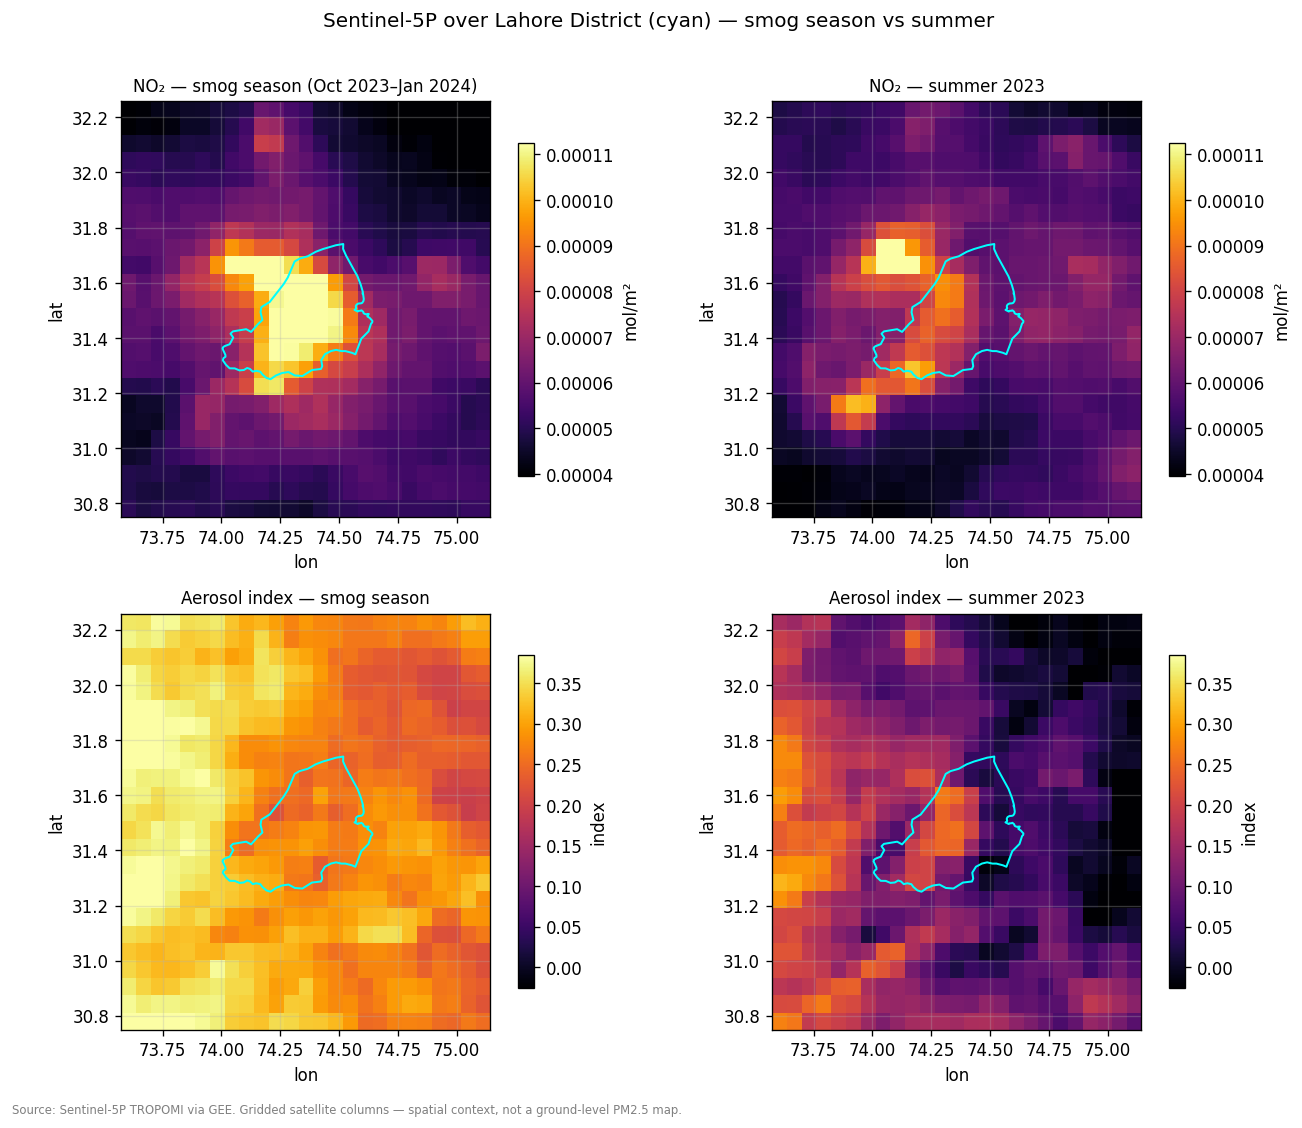

In [2]:
import rasterio
from rasterio.plot import show
import geopandas as gpd
bound = gpd.read_file('../data/raw/boundary/lahore_district_gadm41.shp')

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
panels = [('no2','smog_2023_OctJan','NO₂ — smog season (Oct 2023–Jan 2024)'),
          ('no2','summer_2023','NO₂ — summer 2023'),
          ('aai','smog_2023_OctJan','Aerosol index — smog season'),
          ('aai','summer_2023','Aerosol index — summer 2023')]
# shared scale within each pollutant
def vlim(layer):
    vals=[]
    for season in ['smog_2023_OctJan','summer_2023']:
        with rasterio.open(f'{FIG}/maps/s5p_{layer}_{season}.tif') as r:
            a=r.read(1); vals.append(a[np.isfinite(a)])
    allv=np.concatenate(vals); return np.nanpercentile(allv,2), np.nanpercentile(allv,98)
lims={'no2':vlim('no2'),'aai':vlim('aai')}
for ax,(layer,season,title) in zip(axes.ravel(), panels):
    with rasterio.open(f'{FIG}/maps/s5p_{layer}_{season}.tif') as r:
        arr=r.read(1); arr=np.where(np.isfinite(arr),arr,np.nan)
        ext=[r.bounds.left,r.bounds.right,r.bounds.bottom,r.bounds.top]
    vmin,vmax=lims[layer]
    im=ax.imshow(arr,extent=ext,origin='upper',cmap='inferno',vmin=vmin,vmax=vmax)
    bound.boundary.plot(ax=ax,color='cyan',lw=1.2)
    ax.set_title(title,fontsize=10); ax.set_xlabel('lon'); ax.set_ylabel('lat')
    fig.colorbar(im,ax=ax,shrink=.8,label=('mol/m²' if layer=='no2' else 'index'))
fig.suptitle('Sentinel-5P over Lahore District (cyan) — smog season vs summer', y=1.01, fontsize=12)
fig.text(.01,-.01,'Source: Sentinel-5P TROPOMI via GEE. Gridded satellite columns — spatial context, not a ground-level PM2.5 map.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/maps_s5p_seasonal.png', bbox_inches='tight'); plt.show()

## PM2.5 calendar heatmap

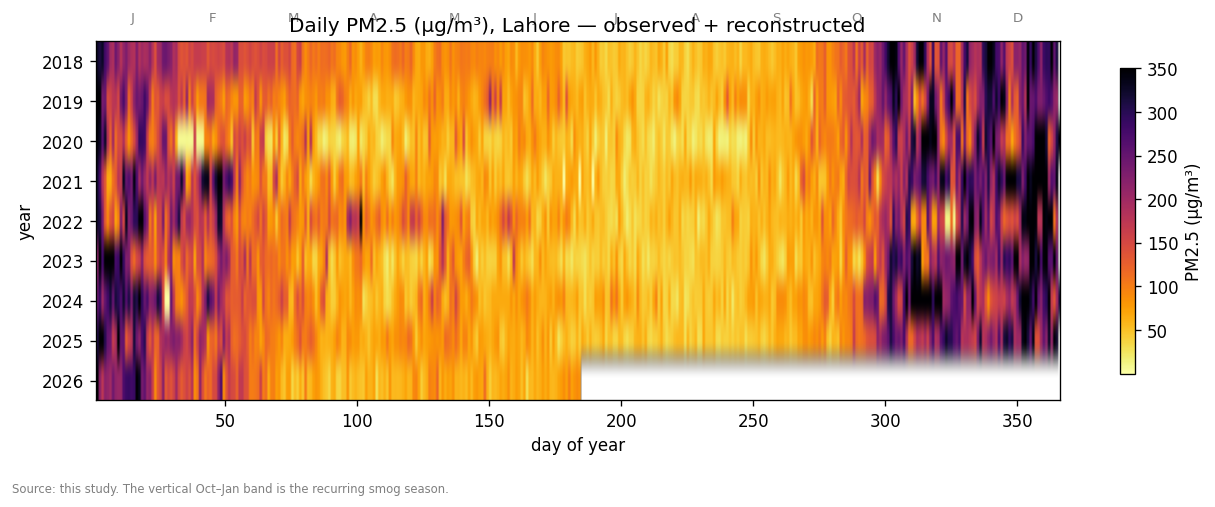

In [3]:
piv = rec.pivot_table(index=rec.date.dt.dayofyear, columns='year', values='pm25_final')
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(piv.T, aspect='auto', cmap='inferno_r',
               extent=[1, 366, piv.columns.max()+.5, piv.columns.min()-.5], vmax=350)
ax.set_yticks(piv.columns); ax.set_xlabel('day of year'); ax.set_ylabel('year')
ax.set_title('Daily PM2.5 (µg/m³), Lahore — observed + reconstructed')
for m,x in zip('J F M A M J J A S O N D'.split(), np.linspace(15,350,12)):
    ax.text(x, piv.columns.min()-1, m, ha='center', fontsize=8, color='gray')
fig.colorbar(im, ax=ax, shrink=.85, label='PM2.5 (µg/m³)')
fig.text(.01,-.04,'Source: this study. The vertical Oct–Jan band is the recurring smog season.', fontsize=7, color='gray')
ax.grid(False)
plt.tight_layout(); plt.savefig(f'{FIG}/calendar_heatmap.png', bbox_inches='tight'); plt.show()

## Seasonal-trend decomposition

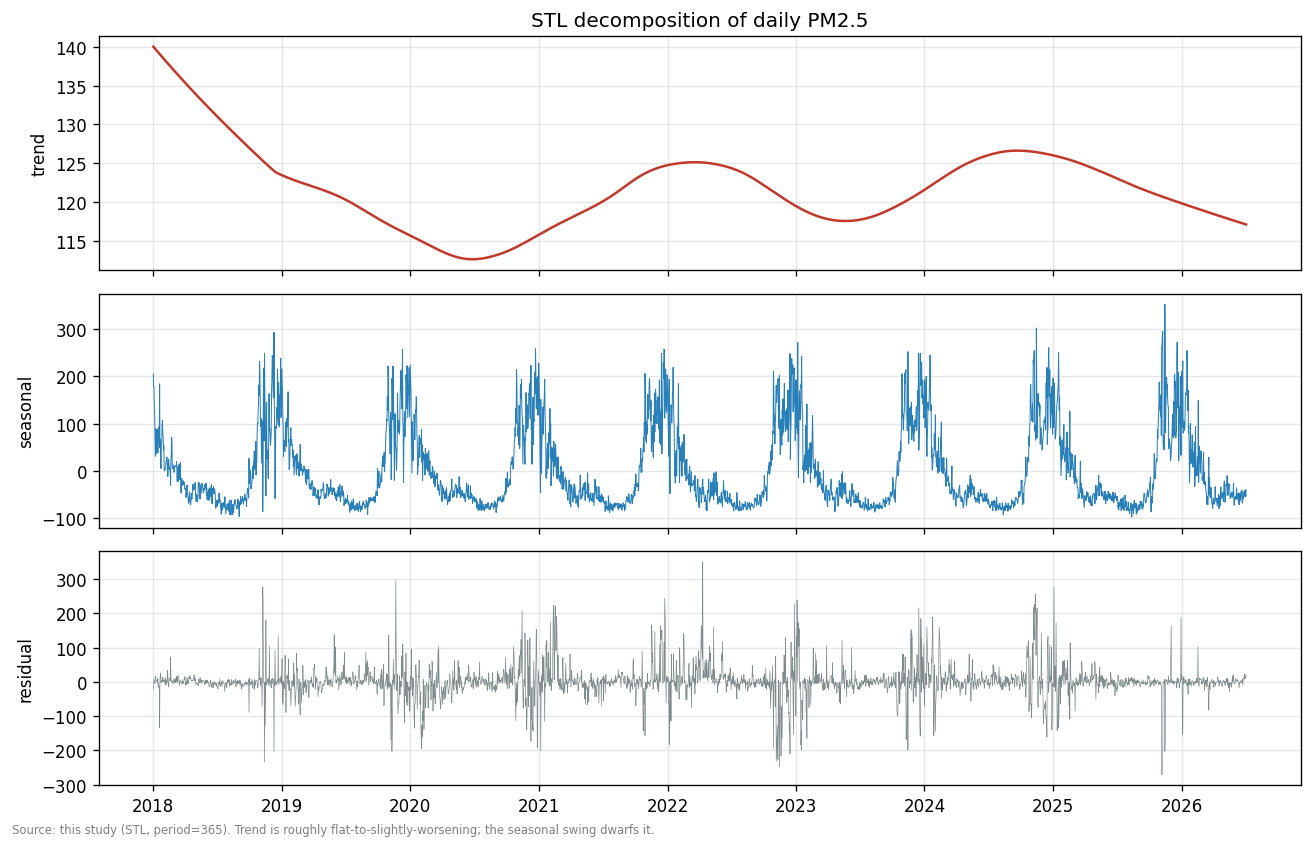

trend range (µg/m³): 112.7 → 140.0


In [4]:
from statsmodels.tsa.seasonal import STL
s = rec.set_index('date').pm25_final.asfreq('D').interpolate()
res = STL(s, period=365, robust=True).fit()
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(res.trend, color='#c0392b'); axes[0].set_ylabel('trend')
axes[0].set_title('STL decomposition of daily PM2.5')
axes[1].plot(res.seasonal, color='#2980b9', lw=.6); axes[1].set_ylabel('seasonal')
axes[2].plot(res.resid, color='#7f8c8d', lw=.4); axes[2].set_ylabel('residual')
axes[2].xaxis.set_major_locator(mdates.YearLocator())
fig.text(.01,.0,'Source: this study (STL, period=365). Trend is roughly flat-to-slightly-worsening; the seasonal swing dwarfs it.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/stl_decomposition.png', bbox_inches='tight'); plt.show()
print('trend range (µg/m³):', round(res.trend.min(),1), '→', round(res.trend.max(),1))

## Hero figure — the story in one image

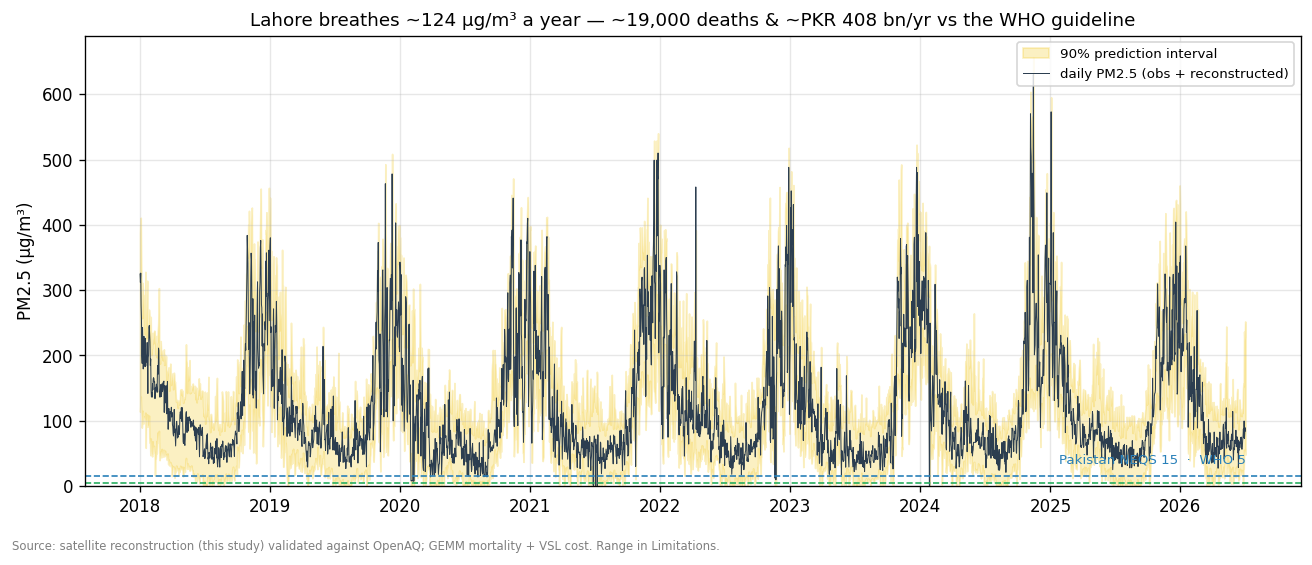

In [5]:
import json
summary = json.load(open('../data/processed/cost_summary.json'))
fig, ax = plt.subplots(figsize=(11, 4.5))
d = rec.sort_values('date')
ax.fill_between(d.date, d.pm25_lo, d.pm25_hi, color='#f1c40f', alpha=.25, label='90% prediction interval')
ax.plot(d.date, d.pm25_final, lw=.6, color='#2c3e50', label='daily PM2.5 (obs + reconstructed)')
ax.axhline(5, color='#27ae60', ls='--', lw=1)
ax.axhline(15, color='#2980b9', ls='--', lw=1)
ax.text(d.date.max(), 30, 'Pakistan NEQS 15  ·  WHO 5', color='#2980b9',
        fontsize=8, ha='right', va='bottom')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.set_ylim(0, None)
ax.set_title(f"Lahore breathes ~{summary['exposure_multiyear_ugm3']:.0f} µg/m³ a year — "
             f"~{summary['headline_deaths_who_cf']//1000},000 deaths & ~PKR {summary['headline_cost_pkr_bn_who_cf']:.0f} bn/yr vs the WHO guideline",
             fontsize=11)
ax.legend(loc='upper right', fontsize=8)
fig.text(.01,-.03,'Source: satellite reconstruction (this study) validated against OpenAQ; GEMM mortality + VSL cost. Range in Limitations.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/hero.png', bbox_inches='tight', dpi=150); plt.show()

All figures exported to `figures/`. These feed the Quarto article, the README hero, and the Streamlit app.